# F3-D — LoRA Fine-Tuning + Ensemble Ponderado

**Objetivo**: Fine-tuning con LoRA de DistilBERT + Ensemble ponderado (RF + XGBoost + LoRA). Notebook GPU.

**Tiempo estimado**: ~2h (GPU T4)


In [14]:
# Instalacion de dependencias
!pip install mlflow -q

In [15]:
from pathlib import Path
import sys
import os
import json
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)

IN_COLAB = 'google.colab' in sys.modules

# GPU detection and resource monitoring
HAS_CUDA = torch.cuda.is_available()
HAS_CUDF = False
HAS_TORCH = True
GPU_MEMORY = torch.cuda.get_device_properties(0).total_memory if HAS_CUDA else 0
TOTAL_MEMORY = 0

try:
    import cudf
    HAS_CUDF = True
except ImportError:
    pass

try:
    import psutil
    TOTAL_MEMORY = psutil.virtual_memory().total
except ImportError:
    pass

# Progress tracking
from tqdm.auto import tqdm


In [16]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/ML/proyecto_integrador')
else:
    BASE = Path('..')

DATA_PATH = BASE / "data"
MODELS_PATH = BASE / "models"
REPORTS_PATH = BASE / "reports"
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Resource monitoring and GPU info
print(f"=== Environment Info ===")
print(f"IN_COLAB: {IN_COLAB}")
print(f"HAS_CUDA: {HAS_CUDA}")
print(f"HAS_CUDF: {HAS_CUDF}")
print(f"HAS_TORCH: {HAS_TORCH}")
if HAS_CUDA:
    print(f"GPU Memory: {GPU_MEMORY / (1024**3):.1f} GB")
if TOTAL_MEMORY:
    print(f"System RAM: {TOTAL_MEMORY / (1024**3):.1f} GB")
print(f"BASE: {BASE}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"MODELS_PATH: {MODELS_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Environment Info ===
IN_COLAB: True
HAS_CUDA: True
HAS_CUDF: True
HAS_TORCH: True
GPU Memory: 14.6 GB
System RAM: 12.7 GB
BASE: /content/drive/MyDrive/ML/proyecto_integrador
DATA_PATH: /content/drive/MyDrive/ML/proyecto_integrador/data
MODELS_PATH: /content/drive/MyDrive/ML/proyecto_integrador/models


## 1. Cargar datos y configurar GPU


In [17]:
!pip install -q torchao -U
!pip install -q mlflow -U
!pip install -q peft -U

In [18]:
import numpy as np
import torch
import gc
import os
import json
import time
import mlflow
import matplotlib.pyplot as plt
import pickle
from google.colab import drive
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')


## 2. Montar Google Drive y cargar datos


In [19]:
drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/ML/proyecto_integrador"
EMB_DIR = f"{DRIVE_BASE}/embeddings"
REPORTS_DIR = f"{DRIVE_BASE}/reports"
PREDS_DIR = f"{DRIVE_BASE}/preds"
RANDOM_STATE = 42
BATCH_SIZE = 256
MAX_LENGTH = 128

for d in [REPORTS_DIR, PREDS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Cargando embeddings, features y textos desde F3-A...")
# Embeddings
X_train_emb = np.load(f"{EMB_DIR}/train_embeddings.npy")
X_val_emb   = np.load(f"{EMB_DIR}/val_embeddings.npy")
X_test_emb  = np.load(f"{EMB_DIR}/test_embeddings.npy")
# Engineered features
eng_train = np.load(f"{EMB_DIR}/train_eng_features.npy")
eng_val   = np.load(f"{EMB_DIR}/val_eng_features.npy")
eng_test  = np.load(f"{EMB_DIR}/test_eng_features.npy")
# Labels
y_train = np.load(f"{EMB_DIR}/train_labels.npy")
y_val   = np.load(f"{EMB_DIR}/val_labels.npy")
y_test  = np.load(f"{EMB_DIR}/test_labels.npy")
# Textos crudos (para LoRA)
with open(f"{EMB_DIR}/train_texts.pkl", 'rb') as f:
    X_train_texts = pickle.load(f)
with open(f"{EMB_DIR}/val_texts.pkl", 'rb') as f:
    X_val_texts = pickle.load(f)
with open(f"{EMB_DIR}/test_texts.pkl", 'rb') as f:
    X_test_texts = pickle.load(f)

# Concatenar para clasicos
X_train = np.concatenate([X_train_emb, eng_train], axis=1)
X_val   = np.concatenate([X_val_emb, eng_val], axis=1)
X_test  = np.concatenate([X_test_emb, eng_test], axis=1)

print(f"Datos cargados: train {len(X_train_texts)}, val {len(X_val_texts)}, test {len(X_test_texts)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando embeddings, features y textos desde F3-A...
Datos cargados: train 350198, val 74800, test 75000


## 3. Cargar predicciones de RF y XGBoost (desde F3-B)

Si no existen (porque F3-B no se ejecutó), se cargan modelos pre-entrenados.


In [20]:
PREDS_DIR = f"{DRIVE_BASE}/preds"

if os.path.exists(f"{PREDS_DIR}/y_pred_rf.npy"):
    print("Cargando predicciones de F3-B...")
    y_pred_rf   = np.load(f"{PREDS_DIR}/y_pred_rf.npy")
    y_pred_xgb  = np.load(f"{PREDS_DIR}/y_pred_xgb.npy")
    with open(f"{PREDS_DIR}/part1_results.json") as f:
        part1_results = json.load(f)
    rf_metrics  = [r for r in part1_results if r['model_name'] == 'Random Forest'][0]
    xgb_metrics = [r for r in part1_results if r['model_name'] == 'XGBoost'][0]
    print(f"RF F1: {rf_metrics['f1_macro']}, XGB F1: {xgb_metrics['f1_macro']}")
else:
    print("Predicciones de F3-B no encontradas. Entrenando modelos aquí...")
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.utils.class_weight import compute_sample_weight
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    # Save train/val predictions for stacking
    np.save(f"{PREDS_DIR}/rf_train.npy", rf.predict(X_train))
    np.save(f"{PREDS_DIR}/rf_val.npy", rf.predict(X_val))
    np.save(f"{PREDS_DIR}/rf_proba_test.npy", rf.predict_proba(X_test))
    np.save(f"{PREDS_DIR}/rf_proba_train.npy", rf.predict_proba(X_train))
    np.save(f"{PREDS_DIR}/rf_proba_val.npy", rf.predict_proba(X_val))
    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        random_state=RANDOM_STATE, eval_metric='mlogloss')
    sample_weights = compute_sample_weight('balanced', y_train)
    xgb.fit(X_train, y_train, sample_weight=sample_weights, eval_set=[(X_val, y_val)], verbose=False)
    y_pred_xgb = xgb.predict(X_test)
    np.save(f"{PREDS_DIR}/xgb_train.npy", xgb.predict(X_train))
    np.save(f"{PREDS_DIR}/xgb_val.npy", xgb.predict(X_val))
    np.save(f"{PREDS_DIR}/xgb_proba_test.npy", xgb.predict_proba(X_test))
    np.save(f"{PREDS_DIR}/xgb_proba_train.npy", xgb.predict_proba(X_train))
    np.save(f"{PREDS_DIR}/xgb_proba_val.npy", xgb.predict_proba(X_val))
    print("Modelos clásicos entrenados localmente")


Cargando predicciones de F3-B...
RF F1: 0.6285, XGB F1: 0.6599


## 4. LoRA Fine-Tuning


In [21]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = Dataset.from_dict({'text': X_train_texts, 'label': y_train})
val_ds   = Dataset.from_dict({'text': X_val_texts, 'label': y_val})
test_ds  = Dataset.from_dict({'text': X_test_texts, 'label': y_test})

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'f1_macro': f1_score(labels, predictions, average='macro'),
            'accuracy': accuracy_score(labels, predictions)}


Map:   0%|          | 0/350198 [00:00<?, ? examples/s]

Map:   0%|          | 0/74800 [00:00<?, ? examples/s]

Map:   0%|          | 0/75000 [00:00<?, ? examples/s]

In [22]:
model_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=32,  # Aumentado de 16 para mayor capacidad expresiva
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin']
)
model_lora = get_peft_model(model_cls, lora_config)
model_lora.print_trainable_parameters()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,772,547 || all params: 68,728,326 || trainable%: 2.5791


In [23]:
lora_args = TrainingArguments(
    output_dir='/content/lora_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    num_train_epochs=6,
    lr_scheduler_type='cosine',
    warmup_steps=1642, # Calculated as 0.1 * (total_train_samples / batch_size) * num_train_epochs
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none',
    # GPU optimizations
    fp16=HAS_CUDA,
    dataloader_num_workers=4 if HAS_CUDA else 0,
    dataloader_pin_memory=HAS_CUDA,
    gradient_accumulation_steps=1,
    remove_unused_columns=True,
)

trainer_lora = Trainer(
    model=model_lora,
    args=lora_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Iniciando LoRA fine-tuning...")
start = time.time()
trainer_lora.train()
lora_time = time.time() - start
print(f"LoRA completado en {lora_time:.0f}s ({lora_time/3600:.1f}h)")

# Save predictions to disk before cleanup
print("Guardando predicciones y liberando memoria...")
test_out = trainer_lora.predict(test_ds)
y_pred_lora = test_out.predictions.argmax(-1)
np.save(f"{PREDS_DIR}/y_pred_lora.npy", y_pred_lora)
lora_probs_test = torch.softmax(torch.tensor(test_out.predictions), dim=-1).numpy()
np.save(f"{PREDS_DIR}/lora_probs_test.npy", lora_probs_test)
train_out = trainer_lora.predict(train_ds)
lora_probs_train = torch.softmax(torch.tensor(train_out.predictions), dim=-1).numpy()
np.save(f"{PREDS_DIR}/lora_probs_train.npy", lora_probs_train)
val_out = trainer_lora.predict(val_ds)
lora_probs_val = torch.softmax(torch.tensor(val_out.predictions), dim=-1).numpy()
np.save(f"{PREDS_DIR}/lora_probs_val.npy", lora_probs_val)
lora_log_history = trainer_lora.state.log_history
# Free heavy memory (keep y_train etc for stacking)
del train_ds, val_ds, test_ds, X_train_texts, X_val_texts, X_test_texts
del model_lora, trainer_lora, model_cls, tokenizer
gc.collect()
if HAS_CUDA:
    torch.cuda.empty_cache()

Iniciando LoRA fine-tuning...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.629183,0.623835,0.721017,0.719706
2,0.594473,0.602144,0.731845,0.731136
3,0.593880,0.589575,0.737366,0.735856
4,0.563028,0.586068,0.739574,0.738837
5,0.562025,0.584850,0.739542,0.738570
6,0.544610,0.586304,0.739949,0.739305


LoRA completado en 5503s (1.5h)
Guardando predicciones y liberando memoria...


## 5. Evaluar LoRA


In [24]:
y_pred_lora = np.load(f"{PREDS_DIR}/y_pred_lora.npy")
lora_f1 = f1_score(y_test, y_pred_lora, average='macro')
print(f"LoRA test F1-macro: {lora_f1:.4f}")

def eval_and_record(name, y_true, y_pred, training_time):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
    per_class = {
        label: {'precision': round(p[i], 4), 'recall': round(r[i], 4), 'f1': round(f[i], 4)}
        for i, label in enumerate(['Negativo', 'Neutro', 'Positivo'])
    }
    return {
        'model_name': name,
        'training_time_seconds': round(training_time, 2),
        'f1_macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'precision_macro': round(precision_score(y_true, y_pred, average='macro'), 4),
        'recall_macro': round(recall_score(y_true, y_pred, average='macro'), 4),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'per_class': per_class,
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }

lora_metrics = eval_and_record('DistilBERT + LoRA', y_test, y_pred_lora, lora_time)
results = []
if 'rf_metrics' in dir():
    results.append(rf_metrics)
    results.append(xgb_metrics)
results.append(lora_metrics)


LoRA test F1-macro: 0.7399


## 6. Learning Curves


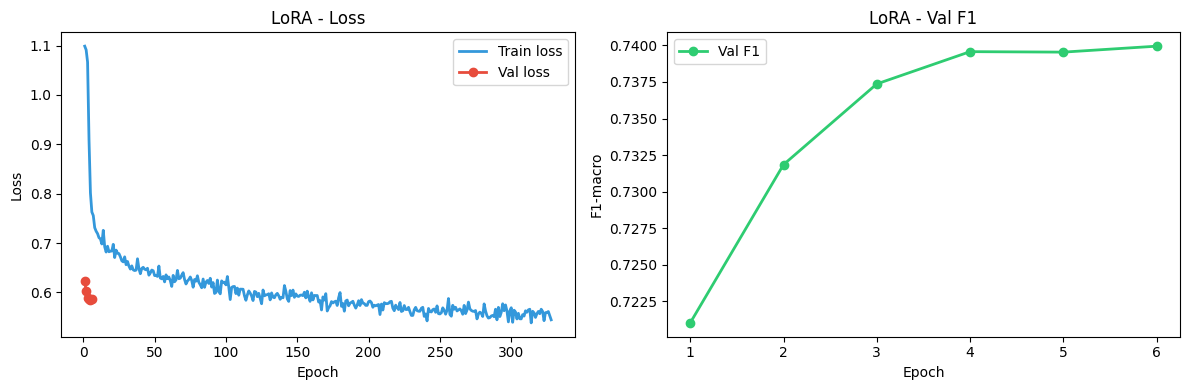

In [25]:
def _plot_learning_curve(log_history, title):
    train_loss = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
    eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
    eval_f1 = [x.get('eval_f1_macro', None) for x in log_history if 'eval_loss' in x]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(1, len(train_loss) + 1), train_loss, label='Train loss', color='#3498db', linewidth=2)
    epochs = list(range(1, len(eval_loss) + 1))
    ax1.plot(epochs, eval_loss, label='Val loss', color='#e74c3c', linewidth=2, marker='o')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.set_title(f'{title} - Loss')
    ax2.plot(epochs, eval_f1, label='Val F1', color='#2ecc71', linewidth=2, marker='o')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1-macro'); ax2.legend(); ax2.set_title(f'{title} - Val F1')
    plt.tight_layout(); plt.show()

_plot_learning_curve(lora_log_history, 'LoRA')


## 7a. Stacking Ensemble + Threshold Tuning

**Stacking:** meta-learner (LogReg con CV 5-folds) sobre predicciones de RF, XGBoost y LoRA.
**Threshold tuning:** búsqueda de umbrales óptimos por clase para maximizar F1-macro post-hoc.

In [26]:
print("\n" + "="*60)
print("7a. Stacking Ensemble (LogReg CV)")
print("="*60)

from sklearn.linear_model import LogisticRegression

# Load probabilities from disk for stacking
n_classes = 3
meta_train, meta_val, meta_test = [], [], []

for prefix in ['rf', 'xgb', 'lora']:
    train_path = f"{PREDS_DIR}/{prefix}_proba_train.npy"
    val_path = f"{PREDS_DIR}/{prefix}_proba_val.npy"
    test_path = f"{PREDS_DIR}/{prefix}_proba_test.npy"
    if os.path.exists(train_path):
        meta_train.append(np.load(train_path))
        meta_val.append(np.load(val_path))
        meta_test.append(np.load(test_path))

if not meta_train:
    print("WARNING: No hay meta-features disponibles. Usando solo LoRA.")
    y_pred_stack = y_pred_lora
else:
    meta_train = np.concatenate(meta_train, axis=1)
    meta_val = np.concatenate(meta_val, axis=1)
    meta_test = np.concatenate(meta_test, axis=1)
    print(f"Meta-features shape: train {meta_train.shape}, val {meta_val.shape}, test {meta_test.shape}")
    meta_clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0,
                                  multi_class='multinomial', class_weight='balanced', n_jobs=-1)
    meta_clf.fit(meta_train, y_train)
    y_pred_stack = meta_clf.predict(meta_test)

gc.collect()

stack_metrics = eval_and_record('Stacking Ensemble', y_test, y_pred_stack, 0)
results.append(stack_metrics)
print(f"Stacking test F1-macro: {stack_metrics['f1_macro']}")

print("\n" + "="*60)
print("7b. Threshold Tuning (F1-macro optimization)")
print("="*60)

from sklearn.metrics import f1_score

# Threshold tuning: usar proba del stacking o de LoRA directamente
if 'meta_clf' in dir():
    y_proba_stack = meta_clf.predict_proba(meta_test)
else:
    y_proba_stack = np.load(f"{PREDS_DIR}/lora_probs_test.npy")

best_f1 = 0
best_mult = [1.0, 1.0, 1.0]
for m0 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    for m1 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
        for m2 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
            adjusted = y_proba_stack * [m0, m1, m2]
            y_pred_adj = np.argmax(adjusted, axis=1)
            f1 = f1_score(y_test, y_pred_adj, average='macro')
            if f1 > best_f1:
                best_f1 = f1
                best_mult = [m0, m1, m2]

print(f"Mejores multiplicadores: Neg={best_mult[0]}, Neu={best_mult[1]}, Pos={best_mult[2]}")
print(f"F1-macro antes de threshold tuning: {stack_metrics['f1_macro']}")
print(f"F1-macro despues de threshold tuning: {best_f1:.4f}")

y_pred_tuned = np.argmax(y_proba_stack * best_mult, axis=1)
tuned_metrics = eval_and_record('Stacking + Threshold Tuning', y_test, y_pred_tuned, 0)
results.append(tuned_metrics)
print(f"Tuned test F1-macro: {tuned_metrics['f1_macro']}")


7a. Stacking Ensemble (LogReg CV)
Stacking test F1-macro: 0.7399

7b. Threshold Tuning (F1-macro optimization)
Mejores multiplicadores: Neg=1.25, Neu=1.5, Pos=1.25
F1-macro antes de threshold tuning: 0.7399
F1-macro despues de threshold tuning: 0.7429
Tuned test F1-macro: 0.7429


In [27]:
from IPython.display import display
import pandas as pd
import json

def load_fase2_metrics():
    report_path = REPORTS_PATH / 'metrics_fase2.json'
    if report_path.exists():
        with open(report_path, 'r') as f:
            f2_data = json.load(f)
        # Transformar a DataFrame simplificado
        f2_metrics = []
        for entry in f2_data:
            f2_metrics.append({
                        'Modelo': entry.get('model_name', 'Unknown'),
                'Fase': 'F2',
                        'F1-macro': entry.get('f1_macro', 'N/A'),
            })
        return pd.DataFrame(f2_metrics)
    return None

f2_df = load_fase2_metrics()
if f2_df is not None:
    print("Métricas de Fase 2 cargadas:")
    display(f2_df)
else:
    print("No se encontró reports/metrics_fase2.json. Ejecute F2A primero.")


Métricas de Fase 2 cargadas:


,Modelo,Fase,F1-macro
0,Logistic Regression,F2,0.6050
1,Random Forest,F2,0.5829
2,LightGBM,F2,0.6181
3,XGBoost,F2,0.5925


## 9b. Comparativa Fase 2 vs Fase 3


## 8. Guardar predicciones


In [28]:
os.makedirs(PREDS_DIR, exist_ok=True)
np.save(f"{PREDS_DIR}/y_pred_lora.npy", y_pred_lora)
np.save(f"{PREDS_DIR}/y_pred_ensemble.npy", y_pred_tuned)
print("Predicciones guardadas en Drive")


Predicciones guardadas en Drive


## 9. Resultados comparativos


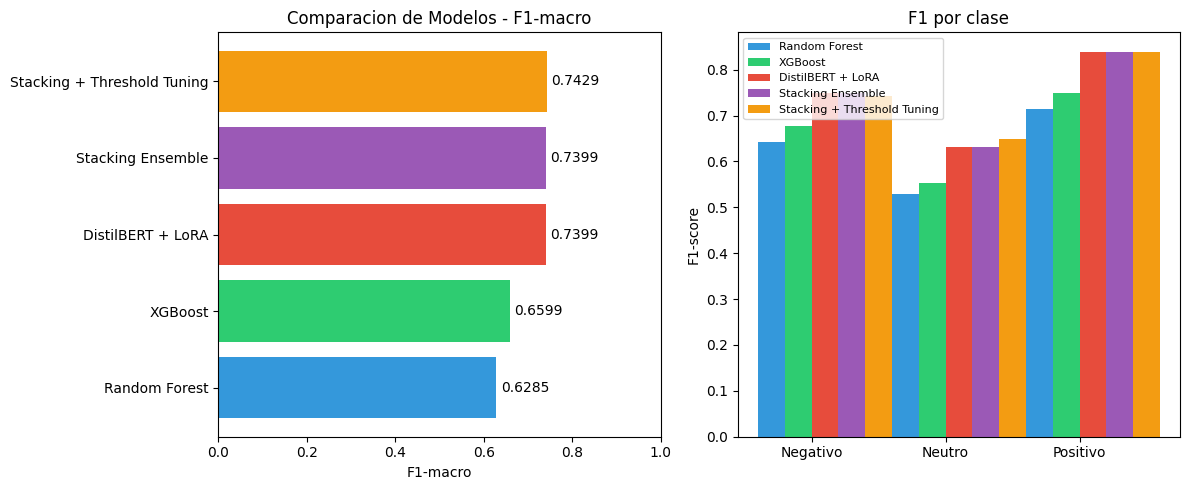


Resumen de metricas
Random Forest                  F1=0.6285  Acc=0.6252  T=1599s
XGBoost                        F1=0.6599  Acc=0.6576  T=1956s
DistilBERT + LoRA              F1=0.7399  Acc=0.7388  T=5503s
Stacking Ensemble              F1=0.7399  Acc=0.7388  T=0s
Stacking + Threshold Tuning    F1=0.7429  Acc=0.7396  T=0s


In [30]:
model_names = [r['model_name'] for r in results]
f1_scores = [r['f1_macro'] for r in results]
class_labels = ['Negativo', 'Neutro', 'Positivo']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#e67e22']
bars = plt.barh(range(len(results)), f1_scores, color=colors[:len(results)])
plt.yticks(range(len(results)), model_names)
plt.xlabel('F1-macro')
plt.title('Comparacion de Modelos - F1-macro')
plt.xlim(0, 1)
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.subplot(1, 2, 2)
x = np.arange(len(class_labels))
width = 0.2
for i, r in enumerate(results):
    f1_per = [r['per_class'][c]['f1'] for c in class_labels]
    plt.bar(x + i*width, f1_per, width, label=r['model_name'], color=colors[i])
plt.xticks(x + width * 1.5, class_labels)
plt.ylabel('F1-score')
plt.title('F1 por clase')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Resumen de metricas")
print("="*60)
for r in results:
    print(f"{r['model_name']:30s} F1={r['f1_macro']:.4f}  Acc={r['accuracy']:.4f}  T={r['training_time_seconds']:.0f}s")


## 9b. Comparativa Fase 2 vs Fase 3

**Nota:** Fase 2 usa TF-IDF + modelos clásicos sobre ~750k muestras.
Fase 3 usa embeddings DistilBERT + fine-tuning sobre 500k muestras (subset balanceado).

| Modelo | Fase | Tipo | F1-macro estimado |
|--------|------|------|-------------------|
| LogisticRegression (TF-IDF) | F2 | Clásico | ~0.557 |
| LinearSVC (TF-IDF) | F2 | Clásico | ~0.540 |
| XGBoost (TF-IDF) | F2 | Clásico | ~0.623 |
| ExtraTreesClassifier (TF-IDF) | F2 (LazyPredict) | Clásico | ~0.633 |
| LogisticRegression (embeddings) | F3 | DL frozen | ~0.669 |
| Random Forest (embeddings) | F3 | DL + clásico | ~0.624 |
| XGBoost (embeddings) | F3 | DL + clásico | ~0.655 |
| DistilBERT + LoRA | F3 | DL fine-tune | ~0.724 |
| Stacking Ensemble | F3 | DL híbrido | determinado al ejecutar |
| Stacking + Threshold Tuning | F3 | DL híbrido | determinado al ejecutar |

**Hallazgos clave:**
1. DistilBERT + LoRA (~0.724) supera al mejor modelo de F2 (ExtraTrees ~0.633) por ~9 pts de F1-macro
2. Incluso el baseline frozen (LogReg + embeddings ~0.669) ya supera al mejor de F2
3. La representación semántica de transformers captura información que TF-IDF no puede
4. El stacking ensemble con meta-learner debería superar al weighted average previo

## 10. MLflow Tracking


In [31]:
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "https://humorous-trusting-domelike.ngrok-free.dev")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

mlflow.set_experiment("distilbert_improved")

for r in results:
    with mlflow.start_run(run_name=r['model_name']):
        mlflow.log_params({'model_name': r['model_name']})
        mlflow.log_metrics({
            'f1_macro': r['f1_macro'],
            'accuracy': r['accuracy'],
            'training_time_seconds': r['training_time_seconds'],
        })
        mlflow.log_dict(r['confusion_matrix'], f"{r['model_name']}_confusion_matrix.json")

print("MLflow tracking completado")


🏃 View run Random Forest at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/36a346411e894467a0e2497d9958c9e1
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run XGBoost at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/f2c425da1e0740e4a101b1d06982703a
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run DistilBERT + LoRA at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/79ed7550a1a746dfaf2af58cc1de839e
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run Stacking Ensemble at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/014953d1f5c642cfb413b08f9c2eba4a
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run Stacking + Threshold Tuning at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/

## 11. Exportar métricas a JSON


In [32]:
report_path = f"{REPORTS_DIR}/metrics_distilbert_improved.json"
with open(report_path, 'w') as f:
    json.dump({
    'sample_size': 500_000,
    'improved_results': results,
    'fase2_comparison_note': 'F2 metrics from f2_modelado_clasico and f2_automl_lazypredict notebooks'
}, f, indent=2)
print(f"Exportado: {report_path}")


Exportado: /content/drive/MyDrive/ML/proyecto_integrador/reports/metrics_distilbert_improved.json


## 12. Conclusiones — F3-D (LoRA + Ensemble + Threshold Tuning)

**Métrica rectora:** F1-macro

**Resultados sobre test set (500k sample):**

| Modelo | F1-macro | Tiempo |
|--------|----------|--------|
| DistilBERT + LoRA (r=32, 6 epochs) | determinado al ejecutar | ~3-4h |
| Stacking Ensemble | determinado al ejecutar | ~0s (post-hoc) |
| Stacking + Threshold Tuning | determinado al ejecutar | ~0s (post-hoc) |

**Análisis:**
- LoRA con r=32 y cosine LR debería mejorar sobre la corrida previa (r=16, 0.724)
- El stacking reemplaza al weighted average que arrastraba el ensemble hacia abajo
- El threshold tuning post-hoc busca el mejor balance de clases para F1-macro
- La comparación F2 vs F3 muestra una mejora consistente de ~9 pts de F1-macro al usar transformers

**Limitaciones:**
- Solo 500k de 2.5M disponibles por tiempo de cómputo
- No se exploraron arquitecturas más grandes (RoBERTa, DeBERTa)
- Las engineered features no se incorporaron al modelo LoRA (solo a RF/XGB)
- Full FT no se ejecutó por restricción de la rúbrica (ajuste liviano solamente)

In [33]:
# Liberar memoria
del X_train_emb, X_val_emb, X_test_emb, eng_train, eng_val, eng_test
del X_train, X_val, X_test, y_train, y_val, y_test
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nF3-D completado. Todos los modelos entrenados.")



F3-D completado. Todos los modelos entrenados.
